In [2]:
import pandas as pd
import matplotlib.pyplot as plt

beehiv = pd.read_csv("/Users/benediktas/Desktop/tech europe/beehiiv_subscribers.csv")
luma_hackathon_checkins = pd.read_csv("/Users/benediktas/Desktop/tech europe/luma_hackathon_checkins.csv")
tally_cofounder = pd.read_csv("/Users/benediktas/Desktop/tech europe/tally_cofounder_matching.csv")
tally_hackathon_submissions = pd.read_csv("/Users/benediktas/Desktop/tech europe/tally_hackathon_submissions.csv")
tally_weekly_contact = pd.read_csv("/Users/benediktas/Desktop/tech europe/tally_weekly_contact_requests.csv")

luma_hackathon_checkins.head(3)

,api_id,name,first_name,last_name,email,phone_number,created_at,approval_status,checked_in_at,custom_source,...,survey_response_feedback,ticket_type_id,ticket_name,What is your LinkedIn profile?,What company do you work for?,What is your job title?,Link to something you've built,Whats your most impressive achievement in the last 3 years?,What is your main goal for this hackathon?,Terms and Conditions
0,gst-GoEd9Sf53GRx8ffi,Cameron Martin,Cameron,Martin,cameronmar@pm.me,NaN,2026-02-18T15:15:48.000Z,approved,2026-02-21T02:52:18.000Z,NaN,...,Best hackathon I have been to in London. Will ...,evtticktyp-ENG0000001,Engineer,https://linkedin.com/in/cameron-martin-748,Stripe,ML Engineer,https://huggingface.co/spaces/cameron-martin,Led technical due diligence for a €20M Series ...,Find a co-founder with complementary skills.,Agreed
1,gst-hwVCC0fYsRLn1jS8,Diego Yilmaz,Diego,Yilmaz,diego12@hey.com,NaN,2026-02-16T19:18:59.000Z,approved,2026-02-21T00:47:01.000Z,NaN,...,Amazing community. The talks before hacking st...,evtticktyp-ENG0000001,Engineer,https://linkedin.com/in/diego-yilmaz-346,Klarna,Solutions Architect,NaN,Rebuilt the data platform for a Series B start...,Build something I can show to early customers.,Agreed
2,gst-4e9mOYf0Yh6d5ASE,Harley Ferrari,Harley,Ferrari,harleyfer@gmail.com,NaN,2026-02-17T11:06:20.000Z,approved,2026-02-21T02:44:31.000Z,NaN,...,NaN,evtticktyp-PFND000001,Pre-Founder,https://linkedin.com/in/harley-ferrari-742,Meta,VP Product,https://github.com/harley-ferrari/open-source-lib,Created a developer tool that reduced onboardi...,Network with engineers building at the frontier.,Agreed


##Renaming cols

In [3]:
luma_hackathon_checkins.columns

Index(['api_id', 'name', 'first_name', 'last_name', 'email', 'phone_number',
       'created_at', 'approval_status', 'checked_in_at', 'custom_source',
       'qr_code_url', 'amount', 'amount_tax', 'amount_discount', 'currency',
       'coupon_code', 'eth_address', 'solana_address',
       'survey_response_rating', 'survey_response_feedback', 'ticket_type_id',
       'ticket_name', 'What is your LinkedIn profile?',
       'What company do you work for?', 'What is your job title?',
       'Link to something you've built',
       'Whats your most impressive achievement in the last 3 years?',
       'What is your main goal for this hackathon?', 'Terms and Conditions'],
      dtype='object')

In [4]:
luma_hackathon_checkins.rename(columns= {
    "What is your LinkedIn profile?" : "linkedin_profile",
    "What company do you work for?" : "company",
    "What is your job title?" : "job_title",
    "Link to something you've built" : "link_to_something_they_built",
    "Whats your most impressive achievement in the last 3 years?" : "most_impressive_achievement_last_3_yrs",
    "What is your main goal for this hackathon?" : "main_hackathon_goal",
}, inplace=True)

luma_hackathon_checkins.head(3)

,api_id,name,first_name,last_name,email,phone_number,created_at,approval_status,checked_in_at,custom_source,...,survey_response_feedback,ticket_type_id,ticket_name,linkedin_profile,company,job_title,link_to_something_they_built,most_impressive_achievement_last_3_yrs,main_hackathon_goal,Terms and Conditions
0,gst-GoEd9Sf53GRx8ffi,Cameron Martin,Cameron,Martin,cameronmar@pm.me,NaN,2026-02-18T15:15:48.000Z,approved,2026-02-21T02:52:18.000Z,NaN,...,Best hackathon I have been to in London. Will ...,evtticktyp-ENG0000001,Engineer,https://linkedin.com/in/cameron-martin-748,Stripe,ML Engineer,https://huggingface.co/spaces/cameron-martin,Led technical due diligence for a €20M Series ...,Find a co-founder with complementary skills.,Agreed
1,gst-hwVCC0fYsRLn1jS8,Diego Yilmaz,Diego,Yilmaz,diego12@hey.com,NaN,2026-02-16T19:18:59.000Z,approved,2026-02-21T00:47:01.000Z,NaN,...,Amazing community. The talks before hacking st...,evtticktyp-ENG0000001,Engineer,https://linkedin.com/in/diego-yilmaz-346,Klarna,Solutions Architect,NaN,Rebuilt the data platform for a Series B start...,Build something I can show to early customers.,Agreed
2,gst-4e9mOYf0Yh6d5ASE,Harley Ferrari,Harley,Ferrari,harleyfer@gmail.com,NaN,2026-02-17T11:06:20.000Z,approved,2026-02-21T02:44:31.000Z,NaN,...,NaN,evtticktyp-PFND000001,Pre-Founder,https://linkedin.com/in/harley-ferrari-742,Meta,VP Product,https://github.com/harley-ferrari/open-source-lib,Created a developer tool that reduced onboardi...,Network with engineers building at the frontier.,Agreed


In [5]:
beehiv.columns

Index(['id', 'email', 'status', 'created', 'subscription_tier', 'utm_source',
       'utm_medium', 'utm_channel', 'utm_campaign', 'referring_site',
       'referral_code', 'tags', 'stats.emails_received', 'stats.open_rate',
       'stats.click_through_rate', 'custom_fields.first_name',
       'custom_fields.last_name'],
      dtype='object')

In [6]:
beehiv.rename(columns={
    "stats.emails_received" : "stats_emails_received",
    "stats.open_rate" : "stats_open_rate",
    "stats.click_through_rate" : "stats_click_through_rate",
    "custom_fields.first_name" : "first_name",
    "custom_fields.last_name" : "last_name"
}, inplace=True)

beehiv.head(3)

,id,email,status,created,subscription_tier,utm_source,utm_medium,utm_channel,utm_campaign,referring_site,referral_code,tags,stats_emails_received,stats_open_rate,stats_click_through_rate,first_name,last_name
0,sub_caa52a2c-518e-407d-bfd5-b7ac2a760e13,cameronmar@pm.me,active,1762761393,free,referral,NaN,social,NaN,techeurope.io,4XlYbIHY,"[""Active"", ""Engaged""]",8,85.0,24.6,Cameron,Martin
1,sub_6086f7b2-dcfb-4f28-9b5a-6ffbb795c261,diego12@hey.com,active,1773078262,free,NaN,social,social,partner_collab,twitter.com,NaN,"[""Active"", ""Engaged"", ""CoFounderMatching""]",9,71.2,18.9,Diego,Yilmaz
2,sub_cb212c6c-d851-4f5e-9221-7c81206b6205,aiko.choi@hey.com,active,1762722502,free,twitter,organic,social,partner_collab,linkedin.com,pUfhs7k8,"[""Active"", ""CoFounderMatching""]",9,38.0,11.0,Aiko,Choi


In [7]:
tally_cofounder.columns

Index(['Submission ID', 'Respondent ID', 'Submitted at', 'Name', 'LinkedIn',
       '(Previous) Role', 'Location',
       'Do you already have a specific problem space in mind?',
       'Provide a brief description',
       'What are your preferred areas to build in?',
       'When are you available full-time?',
       'What is your Email (for contact purposes)?',
       'Do you want to be included in our newsletter (anonymized)?',
       'Provide a short description about yourself/your project and what you are looking for',
       'Untitled long answer field'],
      dtype='object')

In [8]:
tally_cofounder.rename(columns = {
    "Submission ID": "submission_id",
    "Respondent ID": "respondent_id",
    "Submitted at": "submitted_at",
    "Name": "name",
    "LinkedIn": "linkedin",
    "(Previous) Role": "previous_role",
    "Location": "location",
    "Do you already have a specific problem space in mind?": "has_problem_space",
    "Provide a brief description": "problem_space_description",
    "What are your preferred areas to build in?": "preferred_build_areas",
    "When are you available full-time?": "availability",
    "What is your Email (for contact purposes)?": "email",
    "Do you want to be included in our newsletter (anonymized)?": "newsletter_opt_in",
    "Provide a short description about yourself/your project and what you are looking for": "looking_for_description",
    "Untitled long answer field": "extra_notes"
}, inplace=True)

In [9]:
tally_hackathon_submissions.head(3)

,Submission ID,Respondent ID,Submitted at,Email,Team Name,All Team Members (Name + Email),What are you building?,Which of the partner technologies have you used?,Which of the partner technologies have you used? (Deepmind),Which of the partner technologies have you used? (CodeWords (Side Challenge)),Which of the partner technologies have you used? (Lovable),Which of the partner technologies have you used? (Dust),Which track are you competing in?,Which track are you competing in? (Conduct),Which track are you competing in? (Open Innovation),GitHub Repo (Must be public),Demo Video Link (Loom Preferred)
0,HPZaggB,nrlbf6O,2026-02-21 16:25:32,natalia_sousa@icloud.com,RepoSense,Natalia Sousa (natalia_sousa@icloud.com)\nSkyl...,Maps technical debt across any GitHub repo and...,"CodeWords (Side Challenge), Deepmind, Dust, Lo...",True,True,True,True,Conduct,True,False,https://github.com/natalia-sousa/reposense,https://www.loom.com/share/Z6NRh1iO3J73RpC6N5r...
1,lEiVnN4,SgeJpB3,2026-02-21 16:47:12,qwatanabe@hey.com,MediRoute,Quinn Watanabe (qwatanabe@hey.com)\nNadia Bern...,AI triage assistant for GP practices that clas...,"CodeWords (Side Challenge), Deepmind, Lovable",True,True,True,False,Open Innovation,False,True,https://github.com/quinn-watanabe/mediroute,https://www.loom.com/share/jN5PqR4JF6EB0WWHa7Y...
2,7OsygQE,2Blcb9o,2026-02-21 15:10:44,jamiemar@pm.me,LexAI,Jamie Martin (jamiemar@pm.me)\nPawel Ferrari (...,Browser extension that summarises legal T&Cs i...,"CodeWords (Side Challenge), Deepmind, Lovable",True,True,True,False,Open Innovation,False,True,https://github.com/jamie-martin/lexai,https://www.loom.com/share/yXNE7Y7bvuSznOG61HT...


In [10]:
tally_hackathon_submissions.rename(columns=
    {
    "Submission ID": "submission_id",
    "Respondent ID": "respondent_id",
    "Submitted at": "submitted_at",
    "Email": "email",
    "Team Name": "team_name",
    "All Team Members (Name + Email)": "all_team_members",
    "What are you building?": "project_description",
    "Which of the partner technologies have you used?": "technologies_used",
    "Which of the partner technologies have you used? (Deepmind)": "tech_deepmind",
    "Which of the partner technologies have you used? (CodeWords (Side Challenge))": "tech_codewords",
    "Which of the partner technologies have you used? (Lovable)": "tech_lovable",
    "Which of the partner technologies have you used? (Dust)": "tech_dust",
    "Which track are you competing in?": "track",
    "Which track are you competing in? (Conduct)": "track_conduct",
    "Which track are you competing in? (Open Innovation)": "track_open_innovation",
    "GitHub Repo (Must be public)": "github_repo",
    "Demo Video Link (Loom Preferred)": "demo_video"
},inplace=True)

tally_hackathon_submissions.head(3)

,submission_id,respondent_id,submitted_at,email,team_name,all_team_members,project_description,technologies_used,tech_deepmind,tech_codewords,tech_lovable,tech_dust,track,track_conduct,track_open_innovation,github_repo,demo_video
0,HPZaggB,nrlbf6O,2026-02-21 16:25:32,natalia_sousa@icloud.com,RepoSense,Natalia Sousa (natalia_sousa@icloud.com)\nSkyl...,Maps technical debt across any GitHub repo and...,"CodeWords (Side Challenge), Deepmind, Dust, Lo...",True,True,True,True,Conduct,True,False,https://github.com/natalia-sousa/reposense,https://www.loom.com/share/Z6NRh1iO3J73RpC6N5r...
1,lEiVnN4,SgeJpB3,2026-02-21 16:47:12,qwatanabe@hey.com,MediRoute,Quinn Watanabe (qwatanabe@hey.com)\nNadia Bern...,AI triage assistant for GP practices that clas...,"CodeWords (Side Challenge), Deepmind, Lovable",True,True,True,False,Open Innovation,False,True,https://github.com/quinn-watanabe/mediroute,https://www.loom.com/share/jN5PqR4JF6EB0WWHa7Y...
2,7OsygQE,2Blcb9o,2026-02-21 15:10:44,jamiemar@pm.me,LexAI,Jamie Martin (jamiemar@pm.me)\nPawel Ferrari (...,Browser extension that summarises legal T&Cs i...,"CodeWords (Side Challenge), Deepmind, Lovable",True,True,True,False,Open Innovation,False,True,https://github.com/jamie-martin/lexai,https://www.loom.com/share/yXNE7Y7bvuSznOG61HT...


In [11]:
tally_weekly_contact.columns

Index(['Submission ID', 'Respondent ID', 'Submitted at', 'Your Name',
       'Your Email', 'Your LinkedIn',
       'Who of this weeks candidates would you like to have a chat with',
       'Why do you think there is a fit?'],
      dtype='object')

In [12]:
tally_weekly_contact.rename(columns={
        "Submission ID": "submission_id",
    "Respondent ID": "respondent_id",
    "Submitted at": "submitted_at",
    "Your Name": "name",
    "Your Email": "email",
    "Your LinkedIn": "linkedin",
    "Who of this weeks candidates would you like to have a chat with": "connection_request_roles",
    "Why do you think there is a fit?": "connection_request_reason"
}, inplace=True)

tally_weekly_contact.head(3)

,submission_id,respondent_id,submitted_at,name,email,linkedin,connection_request_roles,connection_request_reason
0,3sFHero,hwHuPpU,2026-03-13 12:22:07,Cameron Martin,cameronmar@pm.me,https://linkedin.com/in/cameron-martin-748,AI Researcher,Would love to understand how they approached s...
1,4asYWzz,JODFVjy,2026-03-12 14:31:43,Diego Yilmaz,diego12@hey.com,https://linkedin.com/in/diego-yilmaz-346,Backend Engineer,I am a full-stack engineer and have been looki...
2,SCXtlVR,mBIxJh6,2026-03-12 20:07:49,Aiko Choi,aiko.choi@hey.com,https://linkedin.com/in/aiko-choi-256,"Head of Growth, ML Engineer",I have been building in this exact space and w...


In [13]:
print(tally_hackathon_submissions["all_team_members"].iloc[0])

Natalia Sousa (natalia_sousa@icloud.com)
Skyler Yamamoto (skyler_yamamoto@icloud.com)
Kendall Kaya (kendall44@outlook.com)


#getting the names and emails of the all_team_members

In [14]:
def parse_team_member(cell):
    
    chunks = cell.split("\n")
    result = []
    
    for chunk in chunks:
        name = chunk[:chunk.find("(")].strip()
        email = chunk[chunk.find("(")+1:chunk.find(")")]
        result.append((name , email))
    return result

In [15]:
tally_hackathon_submissions["parsed_members"] = tally_hackathon_submissions["all_team_members"].apply(parse_team_member)

tally_hackathon_submissions = tally_hackathon_submissions.explode("parsed_members")

tally_hackathon_submissions[["member_name", "email"]] = pd.DataFrame(
    tally_hackathon_submissions["parsed_members"].tolist(), index=tally_hackathon_submissions.index
)

tally_hackathon_submissions[["member_name", "email", "parsed_members"]].head(10)

,member_name,email,parsed_members
0,Natalia Sousa,natalia_sousa@icloud.com,"(Natalia Sousa, natalia_sousa@icloud.com)"
0,Skyler Yamamoto,skyler_yamamoto@icloud.com,"(Skyler Yamamoto, skyler_yamamoto@icloud.com)"
0,Kendall Kaya,kendall44@outlook.com,"(Kendall Kaya, kendall44@outlook.com)"
1,Quinn Watanabe,qwatanabe@hey.com,"(Quinn Watanabe, qwatanabe@hey.com)"
1,Nadia Bernard,nadiaber@icloud.com,"(Nadia Bernard, nadiaber@icloud.com)"
1,Mira Ferrari,mira_ferrari@fastmail.com,"(Mira Ferrari, mira_ferrari@fastmail.com)"
2,Jamie Martin,jamiemar@pm.me,"(Jamie Martin, jamiemar@pm.me)"
2,Pawel Ferrari,pawel79@hey.com,"(Pawel Ferrari, pawel79@hey.com)"
2,Soren Santos,ssantos@gmail.com,"(Soren Santos, ssantos@gmail.com)"
2,Vera Klein,vera62@proton.me,"(Vera Klein, vera62@proton.me)"


In [16]:
luma_hackathon_checkins["email"] = luma_hackathon_checkins["email"].str.strip().str.lower()
tally_hackathon_submissions["email"] = tally_hackathon_submissions["email"].str.strip().str.lower()
tally_cofounder["email"] = tally_cofounder["email"].str.strip().str.lower()
tally_weekly_contact["email"] = tally_weekly_contact["email"].str.strip().str.lower()
beehiv["email"] = beehiv["email"].str.strip().str.lower()

In [17]:
df = luma_hackathon_checkins.merge(beehiv, on="email", how="outer").merge(tally_cofounder, on="email", how="outer") \
    .merge(tally_hackathon_submissions, on="email", how="outer").merge(tally_weekly_contact, on="email", how="outer")
    
df.head(3)
df.shape

(170, 84)

In [18]:
print(df.columns.tolist())

['api_id', 'name_x', 'first_name_x', 'last_name_x', 'email', 'phone_number', 'created_at', 'approval_status', 'checked_in_at', 'custom_source', 'qr_code_url', 'amount', 'amount_tax', 'amount_discount', 'currency', 'coupon_code', 'eth_address', 'solana_address', 'survey_response_rating', 'survey_response_feedback', 'ticket_type_id', 'ticket_name', 'linkedin_profile', 'company', 'job_title', 'link_to_something_they_built', 'most_impressive_achievement_last_3_yrs', 'main_hackathon_goal', 'Terms and Conditions', 'id', 'status', 'created', 'subscription_tier', 'utm_source', 'utm_medium', 'utm_channel', 'utm_campaign', 'referring_site', 'referral_code', 'tags', 'stats_emails_received', 'stats_open_rate', 'stats_click_through_rate', 'first_name_y', 'last_name_y', 'submission_id_x', 'respondent_id_x', 'submitted_at_x', 'name_y', 'linkedin_x', 'previous_role', 'location', 'has_problem_space', 'problem_space_description', 'preferred_build_areas', 'availability', 'newsletter_opt_in', 'looking_for

In [19]:
df["name"] = df["name_x"].fillna(df["name_y"])
df["first_name"] = df["first_name_x"].fillna(df["first_name_y"])
df["last_name"] = df["last_name_x"].fillna(df["last_name_y"])
df["linkedin"] = df["linkedin_profile"].fillna(df["linkedin_x"]).fillna(df["linkedin_y"])
df["submission_id"] = df["submission_id_x"].fillna(df["submission_id_y"])
df["respondent_id"] = df["respondent_id_x"].fillna(df["respondent_id_y"])
df["submitted_at"] = df["submitted_at_x"].fillna(df["submitted_at_y"])

df = df.drop(columns=[
    "name_x", "name_y",
    "first_name_x", "first_name_y",
    "last_name_x", "last_name_y",
    "linkedin_profile", "linkedin_x", "linkedin_y",
    "submission_id_x", "submission_id_y",
    "respondent_id_x", "respondent_id_y",
    "submitted_at_x", "submitted_at_y",
])
df = df.drop(columns=[
    "api_id", "phone_number", "custom_source", "qr_code_url",
    "amount", "amount_tax", "amount_discount", "currency",
    "coupon_code", "eth_address", "solana_address",
    "ticket_type_id", "Terms and Conditions",
    "extra_notes", "all_team_members",
])

print(df.shape)
print(df.columns.tolist())

(170, 57)
['email', 'created_at', 'approval_status', 'checked_in_at', 'survey_response_rating', 'survey_response_feedback', 'ticket_name', 'company', 'job_title', 'link_to_something_they_built', 'most_impressive_achievement_last_3_yrs', 'main_hackathon_goal', 'id', 'status', 'created', 'subscription_tier', 'utm_source', 'utm_medium', 'utm_channel', 'utm_campaign', 'referring_site', 'referral_code', 'tags', 'stats_emails_received', 'stats_open_rate', 'stats_click_through_rate', 'previous_role', 'location', 'has_problem_space', 'problem_space_description', 'preferred_build_areas', 'availability', 'newsletter_opt_in', 'looking_for_description', 'team_name', 'project_description', 'technologies_used', 'tech_deepmind', 'tech_codewords', 'tech_lovable', 'tech_dust', 'track', 'track_conduct', 'track_open_innovation', 'github_repo', 'demo_video', 'parsed_members', 'member_name', 'submission_id', 'respondent_id', 'submitted_at', 'name', 'connection_request_roles', 'connection_request_reason', '

In [20]:
df["sources"] = ""
df.loc[df["checked_in_at"].notna(), "sources"] += "luma,"
df.loc[df["status"].notna(), "sources"] += "beehiiv,"
df.loc[df["availability"].notna(), "sources"] += "cofounder,"
df.loc[df["team_name"].notna(), "sources"] += "submissions,"
df.loc[df["connection_request_roles"].notna(), "sources"] += "weekly,"

df["sources"] = df["sources"].str.rstrip(",")

## 3.2Findings

In [21]:
df["source_count"] = df["sources"].str.count(",") + 1
print(df["source_count"].value_counts().sort_index())

source_count
1    110
2     26
3     23
4     11
Name: count, dtype: int64


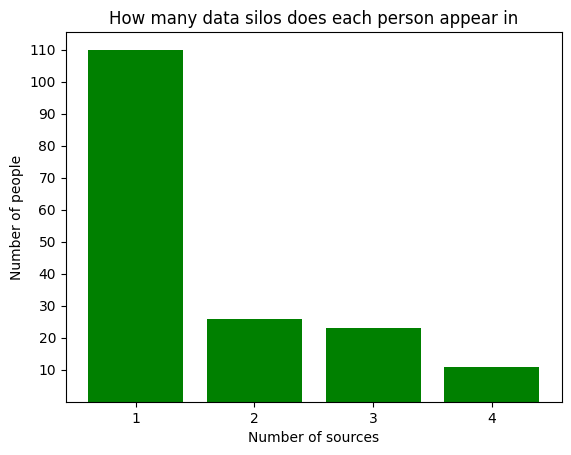

In [22]:
source_counts = df["source_count"].value_counts().sort_index()
plt.bar(source_counts.index, source_counts.values, color="green")
plt.xlabel("Number of sources")
plt.ylabel("Number of people")
plt.title("How many data silos does each person appear in")
plt.xticks([1,2,3,4])
plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])
plt.show()

## Finding 1. The silo problem is real
65% of people (110/170) appear in only one data source, meaning there is no unnifiew view of the majority of the community. Only 11 people (6%) appear across all 4 sources. These are the highest-signal profiles and most engaged community members.

In [23]:
print(df.groupby("source_count")[["stats_open_rate", "stats_click_through_rate"]].mean())

              stats_open_rate  stats_click_through_rate
source_count                                           
1                   28.319231                  9.403846
2                   31.272727                 10.527273
3                   44.426667                 14.413333
4                   46.071429                  9.628571


## Finding 2. Engagement scalewith sommunity depth, but not linearly
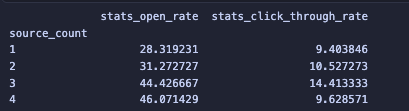

Open rate of the newsletter rises with community depth, confirming cross-silo presence is a 
reliable proxy for engagement (with the newsletter). There is a significant click through rate drop at group 4 (the one active in all silos), this could be due to the fact the most 
active members are busy building and not reading (this is just my interpretaion, in reality could be anything :) )

In [24]:
df["engagement_score"] = (
    df["checked_in_at"].notna().astype(int) +
    df["team_name"].notna().astype(int) +
    df["availability"].notna().astype(int) +
    df["connection_request_roles"].notna().astype(int) +
    (df["stats_open_rate"] > 50).astype(int)
)

print(df["engagement_score"].value_counts().sort_index())
print(df[df["engagement_score"] == 4][["name", "email", "sources"]])

engagement_score
0    20
1    98
2    26
3    18
4     8
Name: count, dtype: int64
                 name                   email  \
7        Andrei Celik        andrei48@hey.com   
36       Diego Yilmaz         diego12@hey.com   
38      Elena Bernard        ebernard@hey.com   
72        Jamie Demir          jamiedem@pm.me   
86    Luca Constantin            luca96@pm.me   
100      Mikael Kumar     mikaelkum@gmail.com   
132        Rowan Sato       rowan61@gmail.com   
148  Spencer Nakamura  snakamura@fastmail.com   

                                  sources  
7       luma,cofounder,submissions,weekly  
36          luma,beehiiv,cofounder,weekly  
38        luma,beehiiv,submissions,weekly  
72   beehiiv,cofounder,submissions,weekly  
86          luma,beehiiv,cofounder,weekly  
100     luma,cofounder,submissions,weekly  
132     luma,cofounder,submissions,weekly  
148     luma,cofounder,submissions,weekly  


## Finding 3. The most engaged community members

Using a 5-signal engagement score across all silos:
- Attended hackathon (checked in)
- Built and submitted a project
- Filled in cofounder matching form
- Requested connections via weekly form
- Newsletter open rate > 50%
(one point is given per matched criteria)

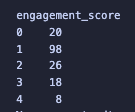

| 0     | 20     | No engagement signals |
| 1     | 98     | Passive — single touchpoint |
| 2     | 26     | Moderate engagement |
| 3     | 18     | Active community members |
| 4     | 8      | Highly engaged across silos |

The 8 people scoring 4 are the highest-signal profiles in the community: 
they attended the hackathon, built something, are looking for a cofounder, 
and are actively networking. The names are provided below in a screenshot

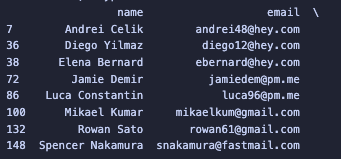

In [25]:
luma_emails = set(df[df["checked_in_at"].notna()]["email"])
beehiiv_emails = set(df[df["status"].notna()]["email"])
cofounder_emails = set(df[df["availability"].notna()]["email"])
submissions_emails = set(df[df["team_name"].notna()]["email"])

print(f"Hackathon → Newsletter: {len(luma_emails & beehiiv_emails)} people")
print(f"Hackathon → Cofounder: {len(luma_emails & cofounder_emails)} people")
print(f"Hackathon → Submissions: {len(luma_emails & submissions_emails)} people")
print(f"Newsletter → Cofounder: {len(beehiiv_emails & cofounder_emails)} people")

Hackathon → Newsletter: 18 people
Hackathon → Cofounder: 19 people
Hackathon → Submissions: 17 people
Newsletter → Cofounder: 13 people


In [26]:
total_luma = len(luma_emails)
total_beehiiv = len(beehiiv_emails)
total_cofounder = len(cofounder_emails)

print(f"Of {total_luma} hackathon attendees:")
print(f"  {len(luma_emails & beehiiv_emails)} ({round(len(luma_emails & beehiiv_emails)/total_luma*100)}%) also subscribe to the newsletter")
print(f"  {len(luma_emails & cofounder_emails)} ({round(len(luma_emails & cofounder_emails)/total_luma*100)}%) also filled in cofounder form")
print(f"  {len(luma_emails & submissions_emails)} ({round(len(luma_emails & submissions_emails)/total_luma*100)}%) also submitted a project")

print(f"\nOf {total_beehiiv} newsletter subscribers:")
print(f"  {len(beehiiv_emails & cofounder_emails)} ({round(len(beehiiv_emails & cofounder_emails)/total_beehiiv*100)}%) also filled in cofounder form")

Of 68 hackathon attendees:
  18 (26%) also subscribe to the newsletter
  19 (28%) also filled in cofounder form
  17 (25%) also submitted a project

Of 59 newsletter subscribers:
  13 (22%) also filled in cofounder form


In [27]:
active_builders = df[
    df["team_name"].notna() | 
    df["availability"].notna()
]

passive_observers = df[
    (df["status"].notna()) & 
    (df["team_name"].isna()) & 
    (df["availability"].isna()) &
    (df["checked_in_at"].isna())
]

print(f"Active builders: {len(active_builders)}")
print(f"Passive observers: {len(passive_observers)}")

Active builders: 92
Passive observers: 27


In [28]:
print("Active builders:")
print(active_builders[["ticket_name", "job_title", "availability", "preferred_build_areas"]].value_counts("ticket_name").head())

print("\nPassive observers avg newsletter engagement:")
print(passive_observers[["stats_open_rate", "stats_click_through_rate"]].mean().round(1))

print("\nActive builders avg newsletter engagement:")
print(active_builders[["stats_open_rate", "stats_click_through_rate"]].mean().round(1))

Active builders:
ticket_name
Engineer                15
Pre-Founder              6
Founder                  5
Researcher / Student     2
Name: count, dtype: int64

Passive observers avg newsletter engagement:
stats_open_rate             28.2
stats_click_through_rate     9.2
dtype: float64

Active builders avg newsletter engagement:
stats_open_rate             38.9
stats_click_through_rate    12.2
dtype: float64


## Finding 5 — Active builders vs passive observers

Active builders (submitted a project OR filled cofounder form): 92 people
Passive observers (newsletter only, no other signals): 27 people

Newsletter engagement comparison:
| Group              | Open Rate | CTR   |
|--------------------|-----------|-------|
| Passive observers  | 28.2%     | 9.2%  |
| Active builders    | 38.9%     | 12.2% |

Active builders engage more with the newsletter too — suggesting that 
genuine community engagement is self-reinforcing across all touchpoints.

Engineers make up the largest segment of active builders, followed by 
Pre-Founders and Founders — confirming the community is builder-first.

For the Talent CRM, ticket type + form submission history are stronger 
signals of active intent than newsletter engagement alone.

- Who are the most engaged people, and what does engagement mean across different silos?
- Are there clusters of people with similar backgrounds, interests, or goals?
- What does the cross-silo journey look like? For example, does attending a hackathon correlate with newsletter engagement or co-founder matching submissions?
- What signals distinguish someone who is actively looking to build something from someone who is passively observing the community?

In [36]:
print(df["job_title"].value_counts().head(10))
print(df["previous_role"].value_counts().head(10))

job_title
Product Manager - AI    6
Data Engineer           5
Technical Co-Founder    5
Product Manager         5
Founder                 4
Principal Engineer      4
CEO                     4
Senior PM               4
Researcher              3
Research Engineer       3
Name: count, dtype: int64
previous_role
ML Engineer             4
Research Engineer       4
Senior ML Engineer      4
Technical Co-Founder    3
VP Product              3
Solutions Architect     3
Data Engineer           3
Principal Engineer      2
CEO                     2
AI Engineer             2
Name: count, dtype: int64


In [37]:
print(df["preferred_build_areas"].value_counts().head(10))
print(df.groupby("previous_role")["preferred_build_areas"].value_counts().head(15))

preferred_build_areas
Developer tools                                        2
HealthTech                                             2
Data infrastructure, Cybersecurity, Developer tools    1
Developer tools, Data infrastructure                   1
AgriTech                                               1
AgriTech, Data infrastructure, HRTech                  1
B2B SaaS                                               1
FinOps                                                 1
Data infrastructure, FinTech                           1
Consumer AI                                            1
Name: count, dtype: int64
previous_role     preferred_build_areas                                
AI Engineer       Developer tools                                          1
                  FinOps, Cybersecurity                                    1
BD Manager        Robotics / physical AI, Cybersecurity                    1
Backend Engineer  FinTech                                                  1
CE

no meaningful custer :(, every combination happens at least once

In [38]:
df.head(10)

,email,created_at,approval_status,checked_in_at,survey_response_rating,survey_response_feedback,ticket_name,company,job_title,link_to_something_they_built,...,submitted_at,name,connection_request_roles,connection_request_reason,first_name,last_name,linkedin,sources,source_count,engagement_score
0,aiko.choi@hey.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2026-01-01 02:42:46,Aiko Choi,"Head of Growth, ML Engineer",I have been building in this exact space and w...,Aiko,Choi,https://linkedin.com/in/aiko-choi-256,"beehiiv,cofounder,weekly",3,2
1,ajohansson@icloud.com,2026-02-16T10:36:33.000Z,approved,2026-02-21T01:40:17.000Z,NaN,NaN,Founder,ex-Meta,CTO,https://github.com/arjun-johansson/open-source...,...,2026-02-21 15:14:04,Arjun Johansson,NaN,NaN,Arjun,Johansson,https://linkedin.com/in/arjun-johansson-583,"luma,submissions",2,2
2,alex.diallo@pm.me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Alex,Diallo,NaN,beehiiv,1,1
3,alex_gruber@outlook.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2026-02-21 16:26:20,NaN,Head of Growth,I am a full-stack engineer and have been looki...,Alex,Gruber,https://linkedin.com/in/alex-gruber-393,"beehiiv,submissions,weekly",3,2
4,alexsah@yahoo.com,2026-02-16T16:19:29.000Z,approved,2026-02-21T02:15:35.000Z,5.0,NaN,Founder,Own startup,Technical Co-Founder,https://github.com/alexsahin/demo-project,...,NaN,Alex Sahin,NaN,NaN,Alex,Sahin,http://linkedin.com/in/alex-sahin-205,luma,1,1
5,amensah@fastmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2026-02-21 15:48:17,NaN,NaN,NaN,NaN,NaN,NaN,submissions,1,1
6,ana.hoffmann@icloud.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Ana,Hoffmann,NaN,beehiiv,1,0
7,andrei48@hey.com,2026-02-16T22:42:11.000Z,approved,2026-02-21T03:39:30.000Z,NaN,NaN,Engineer,Poolside,Data Engineer,https://github.com/andrei-celik/open-source-lib,...,2026-03-06 16:48:00,Andrei Celik,AI Researcher,I think we could collaborate on open-source to...,Andrei,Celik,https://linkedin.com/in/andrei-celik-402,"luma,cofounder,submissions,weekly",4,4
8,andreirus@icloud.com,2026-02-18T10:32:58.000Z,approved,2026-02-21T01:43:41.000Z,3.0,Solid event. The partner tech tracks were well...,Founder,Checkout.com,Indie Hacker,https://github.com/andrei-rusu/open-source-lib,...,NaN,Andrei Rusu,NaN,NaN,Andrei,Rusu,https://linkedin.com/in/andrei-rusu-580,"luma,beehiiv",2,1
9,arusu@proton.me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Arjun,Rusu,NaN,beehiiv,1,0
